Shape of X: (100, 3)
Shape of y: (100, 1)
First 5 rows of X:
 [[3.74540119 9.50714306 7.31993942]
 [5.98658484 1.5601864  1.5599452 ]
 [0.58083612 8.66176146 6.01115012]
 [7.08072578 0.20584494 9.69909852]
 [8.32442641 2.12339111 1.81824967]]
First 5 rows of y:
 [[13.65477759]
 [14.23613937]
 [10.8690698 ]
 [45.57453239]
 [14.64432124]]
Epoch 100/1000, Loss: 4.8923
Epoch 200/1000, Loss: 4.4935
Epoch 300/1000, Loss: 4.2261
Epoch 400/1000, Loss: 4.0468
Epoch 500/1000, Loss: 3.9265
Epoch 600/1000, Loss: 3.8458
Epoch 700/1000, Loss: 3.7917
Epoch 800/1000, Loss: 3.7555
Epoch 900/1000, Loss: 3.7311
Epoch 1000/1000, Loss: 3.7148

Training complete.
Learned Weights:
 [[ 1.59145163]
 [-2.00173595]
 [ 3.15271251]]
Learned Bias:
 [[3.8974086]]

True Weights:
 [[ 1.5]
 [-2. ]
 [ 3. ]]
True Bias:
 5.0


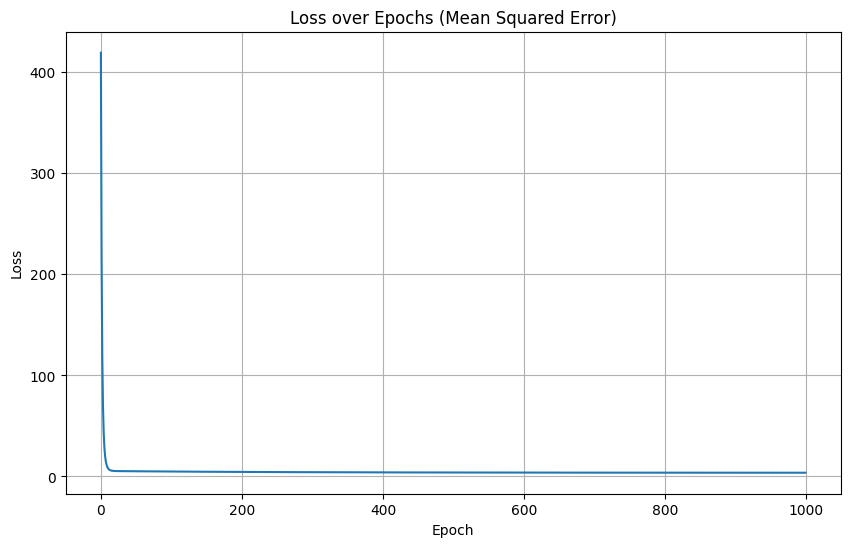

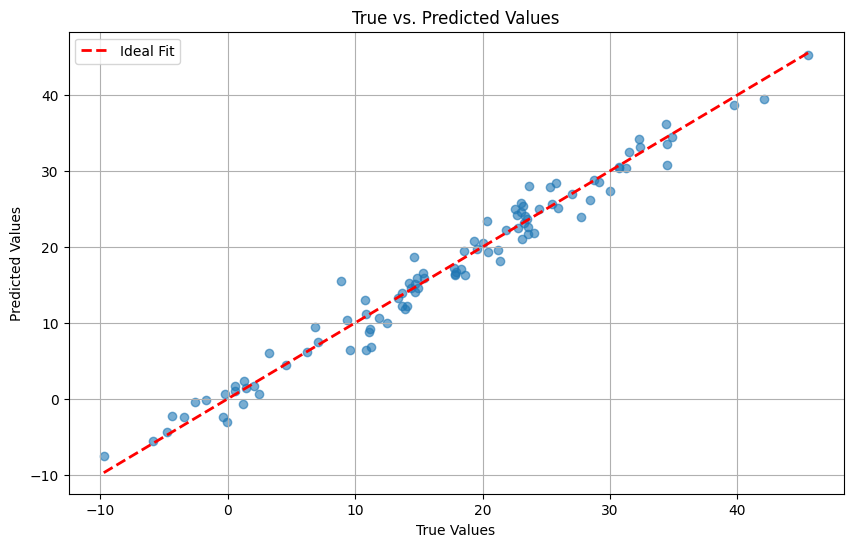

In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

num_samples = 100
num_features = 3

X = np.random.rand(num_samples, num_features) * 10

true_weights = np.array([1.5, -2.0, 3.0]).reshape(num_features, 1)
true_bias = 5.0

y = X @ true_weights + true_bias + np.random.randn(num_samples, 1) * 2

print("Shape of X:", X.shape)
print("Shape of y:", y.shape)
print("First 5 rows of X:\n", X[:5])
print("First 5 rows of y:\n", y[:5])

class LinearRegressionPerceptron:
    def __init__(self, num_features, learning_rate=0.01):
        self.weights = np.random.randn(num_features, 1) * 0.01
        self.bias = np.zeros((1, 1))
        self.learning_rate = learning_rate

    def predict(self, X):
        return np.dot(X, self.weights) + self.bias

    def compute_loss(self, y_predicted, y_true):
        m = y_true.shape[0]
        error = y_predicted - y_true
        loss = (1 / m) * np.sum(np.power(error, 2))
        return loss

    def compute_gradients(self, X, y_predicted, y_true):
        m = y_true.shape[0]
        error = y_predicted - y_true

        dW = (2 / m) * np.dot(X.T, error)
        db = (2 / m) * np.sum(error)
        return dW, db

    def update_parameters(self, dW, db):
        self.weights = self.weights - self.learning_rate * dW
        self.bias = self.bias - self.learning_rate * db

    def train(self, X, y, epochs):
        losses = []
        for epoch in range(epochs):
            y_predicted = self.predict(X)

            loss = self.compute_loss(y_predicted, y)
            losses.append(loss)

            dW, db = self.compute_gradients(X, y_predicted, y)

            self.update_parameters(dW, db)

            if (epoch + 1) % 100 == 0:
                print(f"Epoch {epoch+1}/{epochs}, Loss: {loss:.4f}")
        return losses

num_features = X.shape[1]
model = LinearRegressionPerceptron(num_features, learning_rate=0.01)

epochs = 1000
losses = model.train(X, y, epochs)

print("\nTraining complete.")
print("Learned Weights:\n", model.weights)
print("Learned Bias:\n", model.bias)
print("\nTrue Weights:\n", true_weights)
print("True Bias:\n", true_bias)

plt.figure(figsize=(10, 6))
plt.plot(range(epochs), losses)
plt.title('Loss over Epochs (Mean Squared Error)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True)
plt.show()

y_predicted = model.predict(X)

plt.figure(figsize=(10, 6))
plt.scatter(y, y_predicted, alpha=0.6)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2, label='Ideal Fit')
plt.title('True vs. Predicted Values')
plt.xlabel('True Values')
plt.ylabel('Predicted Values')
plt.grid(True)
plt.legend()
plt.show()